# Molecular dynamics: a recorded experiment

This notebook has already run. Its plots and particle trajectories are saved in
this page. Press **Play** under a particle view to explore the recorded motion;
no Python kernel or running simulation is needed for playback.

We use reduced units: σ = ε = m = kB = 1.

In [1]:
from fys2160_md import FCC, Random, Simulation
import matplotlib.pyplot as plt

## A vibrating crystal

Start 256 atoms on an FCC lattice at density 0.9 and temperature 0.15. This short
run illustrates motion about lattice sites, rather than estimating a precise thermodynamic average.

In [2]:
crystal = FCC(N=256, rho=.9, temperature=.15)
solid = Simulation.run(crystal, steps=2000, save_every=20, storage_name="crystal")
solid.view(max_frames=101, zoom=1.4)

## A dilute gas

Random placement keeps atoms initially at least 0.9σ apart, including across
periodic boundaries. The particles keep the same physical radius in both views.

In [3]:
gas = Random(N=108, rho=.03, min_distance=.9, temperature=2)
result = Simulation.run(gas, steps=3000, save_every=30, storage_name="gas")
result.view(max_frames=101, projection="perspective", zoom=1.4)

## Read the thermodynamic output

The time series records the measured temperature and pressure. An instantaneous
pressure can fluctuate strongly; a mean over an equilibrated run is more useful.

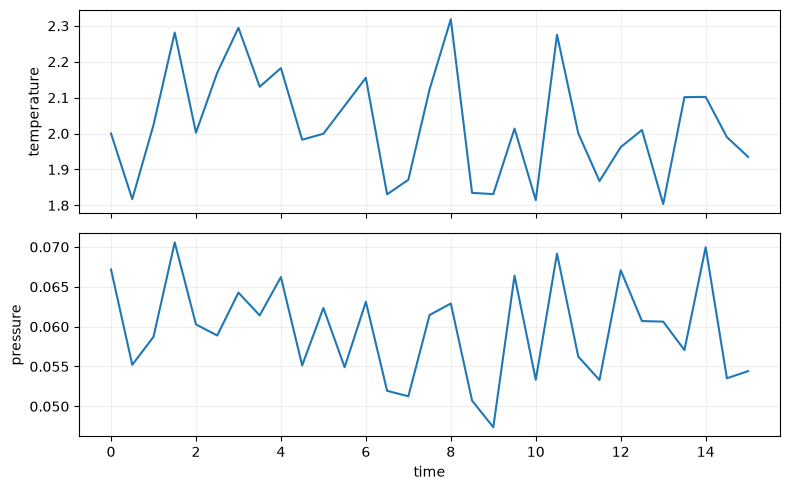

Mean temperature: 2.026
Mean Z: 0.980


In [4]:
result.plot("temperature", "pressure")
plt.show()
print(f"Mean temperature: {result.thermo.temperature.mean():.3f}")
print(f"Mean Z: {result.thermo.compressibility_factor.mean():.3f}")

## Keep the result

The run also exists as `runs/gas` on the machine that executed this notebook.
Later, `Run.load("runs/gas")` reads those files without running MD again.
The players above contain their own sampled trajectory data, so this HTML page
remains interactive even without access to that folder.